In [3]:
d = 251
print(381520/d) 
print(95380/d)

1520.0
380.0


In [4]:
380*4


1520

In [29]:
import json
import subprocess
import re
from itertools import product
import xarray as xr
import pandas as pd
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt


with open("dpa_tune_settings.json", 'r') as file:
        settings = json.load(file)

print("output_dir:", settings['output_dir'])
alt_output_dir = "/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_tuning_output_missed_jobs/"
print("alternative output_dir:", alt_output_dir)


output_dir: /work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_tuning_output/
alternative output_dir: /work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_tuning_output_missed_jobs/


In [2]:
# MAKE SURE THESE ARE CORRECTLY DEFINED
#latent_dims=[10, 20, 50]
#encoder=["learnable", "PCA"]
#hidden_dim_NNs=[50, 100]
#num_layers_NNs=[4, 6]
#noise_dim_dec=[5, 10, 20]
# latent map
#hidden_dim_lm=[20, 50]
#noise_dim_lm=[20, 100]
#training
#lambdas=[0.0, 0.5, 1.0]

###
# 1) Define your coordinate values
coords = {
    'latent_dim':    [10, 20, 50],
    'encoder':       ['learnable', 'PCA'],
    'hidden_dim_NN': [50, 100],
    'num_layers_NN': [4, 6],
    'noise_dim_dec': [5, 10, 20],
    'hidden_dim_lm': [20, 50],
    'noise_dim_lm':  [20, 100],
    'lamb':        [0.0, 0.5, 1.0],
    'epoch':         np.arange(1, 101),          # 0 … 100 inclusive
    'mode':          ['train', 'test'],
    'loss':          ['Total loss','Total S1','Total S2',
                      'DPA NRGY','DPA s1','DPA s2',
                      'LM NRGY','LM s1','LM s1']
}


#save_dir = f"{settings['output_dir']}_{latent_dim}_{num_layers}_{hidden_dim}_{noise_dim_dec}_{in_dim_lm}_{noise_dim_lm}_{num_layers_lm}_{hidden_dim_lm}_encoderis{encoder}_lambda{lam}/"

In [3]:
# Generate all combinations as tuples
combos = list(product(
    coords['latent_dim'],
    coords['encoder'],
    coords['hidden_dim_NN'],
    coords['num_layers_NN'],
    coords['noise_dim_dec'],
    coords['hidden_dim_lm'],
    coords['noise_dim_lm'],
    coords['lamb']
))

# If you prefer a list of dicts:
param_names = [
    "latent_dim", "encoder", "hidden_dim_NN", "num_layers_NN",
    "noise_dim_dec", "hidden_dim_lm", "noise_dim_lm", "lambda"
]
combo_dicts = [dict(zip(param_names, vals)) for vals in combos]

In [4]:
combo_dicts

[{'latent_dim': 10,
  'encoder': 'learnable',
  'hidden_dim_NN': 50,
  'num_layers_NN': 4,
  'noise_dim_dec': 5,
  'hidden_dim_lm': 20,
  'noise_dim_lm': 20,
  'lambda': 0.0},
 {'latent_dim': 10,
  'encoder': 'learnable',
  'hidden_dim_NN': 50,
  'num_layers_NN': 4,
  'noise_dim_dec': 5,
  'hidden_dim_lm': 20,
  'noise_dim_lm': 20,
  'lambda': 0.5},
 {'latent_dim': 10,
  'encoder': 'learnable',
  'hidden_dim_NN': 50,
  'num_layers_NN': 4,
  'noise_dim_dec': 5,
  'hidden_dim_lm': 20,
  'noise_dim_lm': 20,
  'lambda': 1.0},
 {'latent_dim': 10,
  'encoder': 'learnable',
  'hidden_dim_NN': 50,
  'num_layers_NN': 4,
  'noise_dim_dec': 5,
  'hidden_dim_lm': 20,
  'noise_dim_lm': 100,
  'lambda': 0.0},
 {'latent_dim': 10,
  'encoder': 'learnable',
  'hidden_dim_NN': 50,
  'num_layers_NN': 4,
  'noise_dim_dec': 5,
  'hidden_dim_lm': 20,
  'noise_dim_lm': 100,
  'lambda': 0.5},
 {'latent_dim': 10,
  'encoder': 'learnable',
  'hidden_dim_NN': 50,
  'num_layers_NN': 4,
  'noise_dim_dec': 5,
  'hi

In [5]:
def load_and_validate(path, validator):
    """
    Load the file at `path` and run `validator(obj)`.
    Raise FileNotFoundError if missing, or ValueError if validator fails.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"No such file: {path}")
    
    # Example for JSON; swap out for pd.read_csv, pickle.load, etc.
    #with open(path, 'r') as f:
        #obj = json.load(f)
    df = pd.read_csv(
            path,
            skipinitialspace=True,
            dtype={'Epoch': str}
        )

    if not validator(df):
        raise ValueError(f"Validation failed for file: {path}")
    df_data = get_train_test(df)
    return df_data

def get_train_test(df):
    # split into Train vs Test
    is_train = df['Epoch'].str.startswith('Train')
    is_test  = df['Epoch'].str.startswith('Test')

    train_df = df[is_train].reset_index(drop=True)
    test_df  = df[is_test].reset_index(drop=True)

    # get numeric columns and arrays
    numeric_cols = df.columns.drop('Epoch')
    train_array = train_df[numeric_cols].to_numpy()
    test_array  = test_df[numeric_cols].to_numpy()
    return train_array, test_array

# --- Your custom validation function ---
def col_no(df):
    train_array, test_array = get_train_test(df)
    
    if test_array.shape[0] == 100:
        prop = True
    else:
        print(f"[{i}] Test array length: {test_array.shape[0]}")
        prop = False
    return prop

In [6]:
# 2) Create an empty Dataset filled with NaNs
ds = xr.Dataset(
    coords={k: ( [k], v ) for k, v in coords.items()},
    data_vars={
        'value': ( list(coords.keys()), 
                   np.full([len(v) for v in coords.values()], np.nan) )
    }
)
# dims of ds['value'] are in the order of coords.keys()

# 3) Function to parse hyperparameters from filename
def parse_filename(fname):
    """
    example filename:
    _10_4_50_10_1001_20_2_50_encoderislearnable_lambda0.0
    _latentdim(0)_numlayers(1)_hiddendim(2)_noisedimdec(3)_indimlm(4)_noisedimlm(5)_numlayerslm(6)_hiddendimlm(7)_encoder(8)_lambda(9)
    Expect filenames like:
      '..._10_PCA_50_4_5_20_20_20_0.5.txt'
    in exactly the same order as coords (except epoch/mode/loss).
    """
    stem = Path(fname).name
    print(stem)
    parts = stem.split('_')
    print("Parts:", parts)
    #print(str(parts[8+1].split('is')[1]))
    print("lambda:", parts[9+1].split('bda')[1])
    return {
        'latent_dim':    int(parts[0+1]),
        'num_layers_NN': int(parts[1+1]),
        'hidden_dim_NN': int(parts[2+1]),
        'noise_dim_dec': int(parts[3+1]),
        'hidden_dim_lm': int(parts[7+1]),
        'noise_dim_lm':  int(parts[5+1]),
        'encoder':       str(parts[8+1].split('is')[1]),
        'lambda':        float(parts[9+1].split('bda')[1]),
    }
    


In [7]:
#i = 0 tuning job wasnt repeated
i = 1
while i < 864:
    print(i)
    save_path = (
        f"{settings['output_dir']}_"
        f"{combo_dicts[i]['latent_dim']}_"
        f"{combo_dicts[i]['num_layers_NN']}_"
        f"{combo_dicts[i]['hidden_dim_NN']}_"
        f"{combo_dicts[i]['noise_dim_dec']}_1001_"
        f"{combo_dicts[i]['noise_dim_lm']}_2_"
        f"{combo_dicts[i]['hidden_dim_lm']}_"
        f"encoderis{combo_dicts[i]['encoder']}_"
        f"lambda{combo_dicts[i]['lambda']}/log.txt"
    )

    alt_save_path = (
        f"{alt_output_dir}_"
        f"{combo_dicts[i]['latent_dim']}_"
        f"{combo_dicts[i]['num_layers_NN']}_"
        f"{combo_dicts[i]['hidden_dim_NN']}_"
        f"{combo_dicts[i]['noise_dim_dec']}_1001_"
        f"{combo_dicts[i]['noise_dim_lm']}_2_"
        f"{combo_dicts[i]['hidden_dim_lm']}_"
        f"encoderis{combo_dicts[i]['encoder']}_"
        f"lambda{combo_dicts[i]['lambda']}/log.txt"
    )
    # --- Load with fallback logic ---
    try:
        df = load_and_validate(save_path, col_no)
        #print(f"Loaded primary logs: {save_path}")
        file_path = Path(save_path)
    
    except (FileNotFoundError, ValueError) as e:
        print(f"[WARN] Primary failed ({e}); loading fallback.")
        print(f"Loading fallback logs: {alt_save_path}")
        df = load_and_validate(alt_save_path, col_no)
        file_path = Path(alt_save_path)
        #print(f"Loaded fallback logs: {alt_save_path}")
    
    train_losses = df[0]
    if np.isnan(train_losses).any():
        print("Contains NaN?", np.isnan(train_losses).any(), np.isnan(train_losses).sum())
    test_losses = df[1]
    if np.isnan(test_losses).any():
        print("Contains NaN?", np.isnan(test_losses).any(), np.isnan(test_losses).sum())

    #print(train_losses.shape, test_losses.shape)
    #print("filepath:", file_path.parent)
    params = parse_filename(file_path.parent)

    ###
    # train values
    ds['value'].loc[
        dict(
          latent_dim=params['latent_dim'],
          encoder=params['encoder'],
          hidden_dim_NN=params['hidden_dim_NN'],
          num_layers_NN=params['num_layers_NN'],
          noise_dim_dec=params['noise_dim_dec'],
          hidden_dim_lm=params['hidden_dim_lm'],
          noise_dim_lm=params['noise_dim_lm'],
          lamb=params['lambda'],
          mode="train",
          #epoch=epoch,
          #loss=loss_name
        )
    ] = train_losses
    ###
    # test loss
    ds['value'].loc[
        dict(
          latent_dim=params['latent_dim'],
          encoder=params['encoder'],
          hidden_dim_NN=params['hidden_dim_NN'],
          num_layers_NN=params['num_layers_NN'],
          noise_dim_dec=params['noise_dim_dec'],
          hidden_dim_lm=params['hidden_dim_lm'],
          noise_dim_lm=params['noise_dim_lm'],
          lamb=params['lambda'],
          mode="test",
          #epoch=epoch,
          #loss=loss_name
        )
    ] = test_losses
    ###
    i += 1
    
    # Now `config` is guaranteed to be a valid object

1
_10_4_50_5_1001_20_2_20_encoderislearnable_lambda0.5
Parts: ['', '10', '4', '50', '5', '1001', '20', '2', '20', 'encoderislearnable', 'lambda0.5']
lambda: 0.5
2
_10_4_50_5_1001_20_2_20_encoderislearnable_lambda1.0
Parts: ['', '10', '4', '50', '5', '1001', '20', '2', '20', 'encoderislearnable', 'lambda1.0']
lambda: 1.0
3
_10_4_50_5_1001_100_2_20_encoderislearnable_lambda0.0
Parts: ['', '10', '4', '50', '5', '1001', '100', '2', '20', 'encoderislearnable', 'lambda0.0']
lambda: 0.0
4
[WARN] Primary failed (No such file: /work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_tuning_output/_10_4_50_5_1001_100_2_20_encoderislearnable_lambda0.5/log.txt); loading fallback.
Loading fallback logs: /work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_tuning_output_missed_jobs/_10_4_50_5_1001_100_2_20_encoderislearnable_lambda0.5/log.txt
_10_4_50_5_1001_100_2_20_encoderislearnable_lambda0.5
Parts: ['', '10', '4', '50', '5', '1001', '100', '2', '

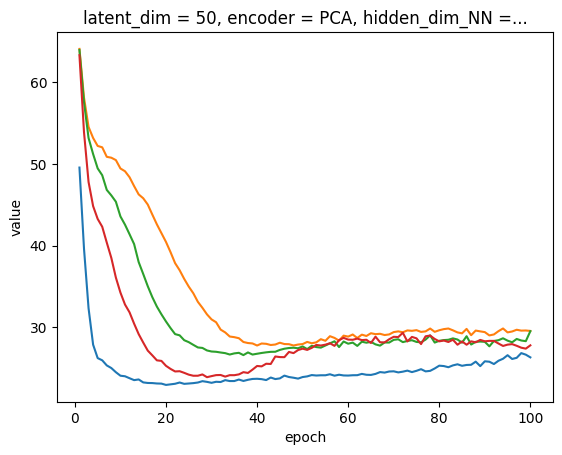

In [10]:
ds.value.sel(latent_dim = 10,
             encoder = 'learnable',
             hidden_dim_NN = 50,
             num_layers_NN = 4,
             noise_dim_dec = 10,
             hidden_dim_lm = 20,
             noise_dim_lm = 100,
             lamb = 0.0,
             mode = 'test',
             loss = 'LM NRGY'
            ).plot()

ds.value.sel(latent_dim = 10,
             encoder = 'PCA',
             hidden_dim_NN = 50,
             num_layers_NN = 4,
             noise_dim_dec = 10,
             hidden_dim_lm = 20,
             noise_dim_lm = 20,
             lamb = 0.5,
             mode = 'test',
             loss = 'LM NRGY'
            ).plot()
ds.value.sel(latent_dim = 10,
             encoder = 'PCA',
             hidden_dim_NN = 50,
             num_layers_NN = 4,
             noise_dim_dec = 10,
             hidden_dim_lm = 20,
             noise_dim_lm = 20,
             lamb = 1.0,
             mode = 'test',
             loss = 'LM NRGY'
            ).plot()
ds.value.sel(latent_dim = 50,
             encoder = 'PCA',
             hidden_dim_NN = 50,
             num_layers_NN = 4,
             noise_dim_dec = 10,
             hidden_dim_lm = 20,
             noise_dim_lm = 20,
             lamb = 1.0,
             mode = 'test',
             loss = 'LM NRGY'
            ).plot()

In [16]:
ds

<xarray.Dataset> Size: 12MB
Dimensions:        (latent_dim: 3, encoder: 2, hidden_dim_NN: 2,
                    num_layers_NN: 2, noise_dim_dec: 3, hidden_dim_lm: 2,
                    noise_dim_lm: 2, lamb: 3, epoch: 100, mode: 2, loss: 9)
Coordinates:
  * latent_dim     (latent_dim) int64 24B 10 20 50
  * encoder        (encoder) <U9 72B 'learnable' 'PCA'
  * hidden_dim_NN  (hidden_dim_NN) int64 16B 50 100
  * num_layers_NN  (num_layers_NN) int64 16B 4 6
  * noise_dim_dec  (noise_dim_dec) int64 24B 5 10 20
  * hidden_dim_lm  (hidden_dim_lm) int64 16B 20 50
  * noise_dim_lm   (noise_dim_lm) int64 16B 20 100
  * lamb           (lamb) float64 24B 0.0 0.5 1.0
  * epoch          (epoch) int64 800B 1 2 3 4 5 6 7 8 ... 94 95 96 97 98 99 100
  * mode           (mode) <U5 40B 'train' 'test'
  * loss           (loss) <U10 360B 'Total loss' 'Total S1' ... 'LM s1' 'LM s1'
Data variables:
    value          (latent_dim, encoder, hidden_dim_NN, num_layers_NN, noise_dim_dec, hidden_dim_lm, noise_dim_lm, lamb, epoch, mode, loss) float64 12MB ...

value=20.6303 at {'latent_dim': 50, 'encoder': 'learnable', 'hidden_dim_NN': 50, 'num_layers_NN': 4, 'noise_dim_dec': 20, 'hidden_dim_lm': 20, 'noise_dim_lm': 20, 'lamb': 0.5}
value=20.6554 at {'latent_dim': 50, 'encoder': 'learnable', 'hidden_dim_NN': 50, 'num_layers_NN': 6, 'noise_dim_dec': 5, 'hidden_dim_lm': 50, 'noise_dim_lm': 20, 'lamb': 0.5}
value=20.6771 at {'latent_dim': 50, 'encoder': 'learnable', 'hidden_dim_NN': 50, 'num_layers_NN': 4, 'noise_dim_dec': 20, 'hidden_dim_lm': 20, 'noise_dim_lm': 20, 'lamb': 1.0}
value=20.6836 at {'latent_dim': 50, 'encoder': 'learnable', 'hidden_dim_NN': 50, 'num_layers_NN': 6, 'noise_dim_dec': 5, 'hidden_dim_lm': 50, 'noise_dim_lm': 20, 'lamb': 0.5}
value=20.6972 at {'latent_dim': 50, 'encoder': 'learnable', 'hidden_dim_NN': 50, 'num_layers_NN': 4, 'noise_dim_dec': 10, 'hidden_dim_lm': 50, 'noise_dim_lm': 20, 'lamb': 0.5}


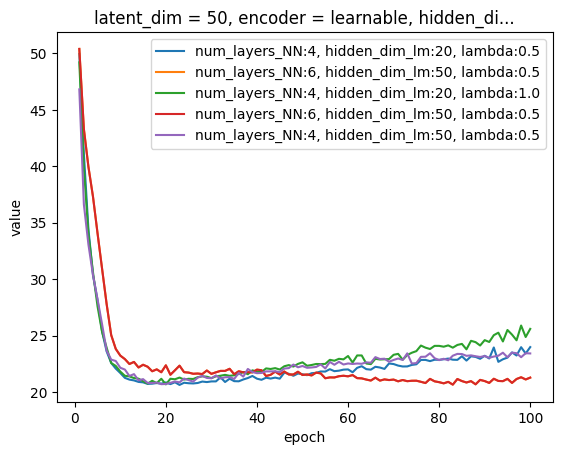

In [36]:
# 1) Turn it into a pandas Series with a MultiIndex
ser = ds.value.sel(loss = 'LM NRGY', mode = 'test', lamb = [0.5, 1.0]).to_series()

# 2) Pick off the 5 smallest values
smallest = ser.nsmallest(5)

# 3) `smallest` is a Series whose index is a tuple of coordinate labels
for coord_tuple, value in smallest.items():
    coords = dict(zip(ds.value.dims, coord_tuple))
    epoch = coords.pop('epoch')
    ds.value.sel(coords).sel(loss = 'LM NRGY', mode = 'test').plot(label = f"num_layers_NN:{coords['num_layers_NN']}, hidden_dim_lm:{coords['hidden_dim_lm']}, lambda:{coords['lamb']}")
    #plt.show()
    plt.legend()
    print(f"value={value:.4f} at {coords}")
plt.show()




2nd smallest LM NRGY = 20.6554 at {'latent_dim': np.int64(50), 'encoder': 'learnable', 'hidden_dim_NN': np.int64(50), 'num_layers_NN': np.int64(6), 'noise_dim_dec': np.int64(5), 'hidden_dim_lm': np.int64(50), 'noise_dim_lm': np.int64(20), 'lamb': np.float64(0.5), 'epoch': np.int64(83)}


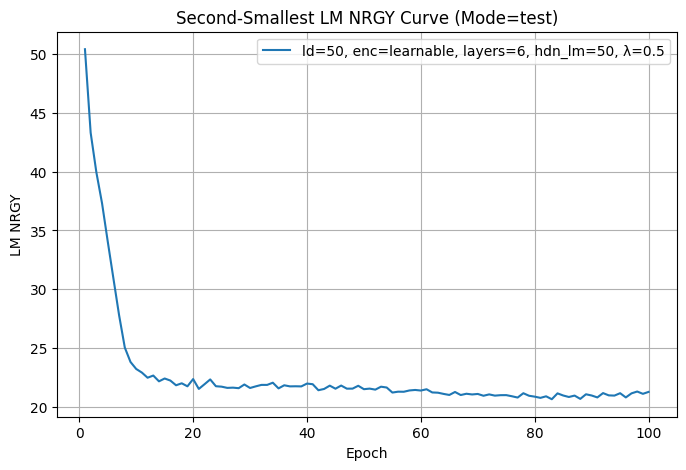

In [42]:
# learnable vs fixed encoder
import matplotlib.pyplot as plt



# 2) Extract the 2nd‐smallest entry
second_coord = smallest.index[1]    # tuple of coords in order da.dims
second_val   = smallest.iloc[1]

# 3) Map that tuple back to a dict of dim→coord
coord_map = dict(zip(ds.dims, second_coord))
print(f"2nd smallest LM NRGY = {second_val:.4f} at {coord_map}")

# 4) Select the full epoch curve for that configuration
curve = ds.value.sel(
    latent_dim    = coord_map['latent_dim'],
    encoder       = coord_map['encoder'],
    hidden_dim_NN = coord_map['hidden_dim_NN'],
    num_layers_NN = coord_map['num_layers_NN'],
    noise_dim_dec = coord_map['noise_dim_dec'],
    hidden_dim_lm = coord_map['hidden_dim_lm'],
    noise_dim_lm  = coord_map['noise_dim_lm'],
    lamb          = coord_map['lamb'],
    mode          = 'test',
    loss          = 'LM NRGY'
)  # dims: ('epoch',)

# 5) Plot it
plt.figure(figsize=(8,5))
plt.plot(curve['epoch'], curve, label=(
    f"ld={coord_map['latent_dim']}, enc={coord_map['encoder']}, "
    f"layers={coord_map['num_layers_NN']}, hdn_lm={coord_map['hidden_dim_lm']}, λ={coord_map['lamb']}"
))
plt.xlabel('Epoch')
plt.ylabel('LM NRGY')
plt.title('Second‐Smallest LM NRGY Curve (Mode=test)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# search for smallest loss value
# vary remaining parameters around it

In [15]:
smallest

latent_dim  encoder  hidden_dim_NN  num_layers_NN  noise_dim_dec  hidden_dim_lm  noise_dim_lm  lamb  epoch  mode   loss    
50          PCA      100            6              20             50             100           0.5   100    train  DPA NRGY    6.5513
                                                                                                     99     train  DPA NRGY    6.5560
                                    4              20             50             100           0.5   100    train  DPA NRGY    6.5632
                                    6              20             50             100           0.5   98     train  DPA NRGY    6.5639
                                    4              20             50             100           0.5   99     train  DPA NRGY    6.5685
Name: value, dtype: float64

In [11]:
#mask = ds.value.isnull()
total_nans = int(ds.value.isnull().sum().values)
print(f"Total NaNs: {total_nans}")

Total NaNs: 1800


In [ ]:
# find out which jobs failed
import os
import pandas as pd
import subprocess


i = 0
while i < 864:
    save_path = (
        f"{settings['output_dir']}_"
        f"{combo_dicts[i]['latent_dim']}_"
        f"{combo_dicts[i]['num_layers_NN']}_"
        f"{combo_dicts[i]['hidden_dim_NN']}_"
        f"{combo_dicts[i]['noise_dim_dec']}_1001_"
        f"{combo_dicts[i]['noise_dim_lm']}_2_"
        f"{combo_dicts[i]['hidden_dim_lm']}_"
        f"encoderis{combo_dicts[i]['encoder']}_"
        f"lambda{combo_dicts[i]['lambda']}/log.txt"
    )

    alt_save_path = (
        f"{alt_output_dir}_"
        f"{combo_dicts[i]['latent_dim']}_"
        f"{combo_dicts[i]['num_layers_NN']}_"
        f"{combo_dicts[i]['hidden_dim_NN']}_"
        f"{combo_dicts[i]['noise_dim_dec']}_1001_"
        f"{combo_dicts[i]['noise_dim_lm']}_2_"
        f"{combo_dicts[i]['hidden_dim_lm']}_"
        f"encoderis{combo_dicts[i]['encoder']}_"
        f"lambda{combo_dicts[i]['lambda']}/log.txt"
    )
    

    # if the file isn't there, check alternative path
    if not os.path.isfile(save_path):
        print(f"[{i}] File not found: {save_path}")
        #i += 1
        #continue

    # read file from tuning 1
    else:
        df = pd.read_csv(
            save_path,
            skipinitialspace=True,
            dtype={'Epoch': str}
        )

    # split into Train vs Test
    is_train = df['Epoch'].str.startswith('Train')
    is_test  = df['Epoch'].str.startswith('Test')

    train_df = df[is_train].reset_index(drop=True)
    test_df  = df[is_test].reset_index(drop=True)

    # get numeric columns and arrays
    numeric_cols = df.columns.drop('Epoch')
    train_array = train_df[numeric_cols].to_numpy()
    test_array  = test_df[numeric_cols].to_numpy()

    print(f"[{i}] Test array length: {test_array.shape[0]}")
    if test_array.shape[0] != 100:
        print("Logs too short")


        
    i += 1


In [ ]:
# find out which jobs failed
import os
import pandas as pd
import subprocess


i = 0
while i < 864:
    save_path = (
        f"{settings['output_dir']}_"
        f"{combo_dicts[i]['latent_dim']}_"
        f"{combo_dicts[i]['num_layers_NN']}_"
        f"{combo_dicts[i]['hidden_dim_NN']}_"
        f"{combo_dicts[i]['noise_dim_dec']}_1001_"
        f"{combo_dicts[i]['noise_dim_lm']}_2_"
        f"{combo_dicts[i]['hidden_dim_lm']}_"
        f"encoderis{combo_dicts[i]['encoder']}_"
        f"lambda{combo_dicts[i]['lambda']}/log.txt"
    )

    # if the file isn't there, print a warning and move on
    if not os.path.isfile(save_path):
        print(f"[{i}] File not found: {save_path}")
        result = subprocess.run(["bash","search_slurm_outfile.sh",
                                 settings['output_dir'],
                                 str(combo_dicts[i]['latent_dim']),             # $2
                                 combo_dicts[i]['encoder'],                     # $3
                                 str(combo_dicts[i]['lambda']),                 # $4
                                 str(combo_dicts[i]['hidden_dim_NN']),           # $5
                                 str(combo_dicts[i]['num_layers_NN']),          # $6
                                 str(combo_dicts[i]['noise_dim_dec']),          # $7
                                 str(combo_dicts[i]['hidden_dim_lm']),          # $8
                                 str(combo_dicts[i]['noise_dim_lm'])],          # $9
                                 check=True)
        i += 1
        continue

    # now safe to read
    try:
        df = pd.read_csv(
            save_path,
            skipinitialspace=True,
            dtype={'Epoch': str}
        )
    except Exception as e:
        print(f"[{i}] Error reading {save_path}: {e}")
        i += 1
        continue

    # split into Train vs Test
    is_train = df['Epoch'].str.startswith('Train')
    is_test  = df['Epoch'].str.startswith('Test')

    train_df = df[is_train].reset_index(drop=True)
    test_df  = df[is_test].reset_index(drop=True)

    # get numeric columns and arrays
    numeric_cols = df.columns.drop('Epoch')
    train_array = train_df[numeric_cols].to_numpy()
    test_array  = test_df[numeric_cols].to_numpy()

    print(f"[{i}] Test array length: {test_array.shape[0]}")
    if test_array.shape[0] != 100:
        # In a notebook cell:
        # find the corresponding slurm out file
        #subprocess.run(["bash", "search_slurm_outfile.sh"], check=True)
        result = subprocess.run(["bash","search_slurm_outfile.sh",
                                 settings['output_dir'],
                                 str(combo_dicts[i]['latent_dim']),             # $2
                                 combo_dicts[i]['encoder'],                     # $3
                                 str(combo_dicts[i]['lambda']),                 # $4
                                 str(combo_dicts[i]['hidden_dim_NN']),           # $5
                                 str(combo_dicts[i]['num_layers_NN']),          # $6
                                 str(combo_dicts[i]['noise_dim_dec']),          # $7
                                 str(combo_dicts[i]['hidden_dim_lm']),          # $8
                                 str(combo_dicts[i]['noise_dim_lm'])],          # $9
                                 check=True)
        
    i += 1
